In [1]:
from pathlib import Path
import pandas as pd
from diffusion_encoder import build_conditional_unet_1d
from timesnet_encoder import TimesBlock
from sequences_peaks_v2 import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


I0000 00:00:1785495812.972049    7914 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

ImportError: sklearn._cyutility does not export expected C function slice_memviewslice

ImportError: sklearn._cyutility does not export expected C function slice_memviewslice

In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-DiffGAN-v6"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: Diffusion v6 (Heavy-Duty 1D U-Net & Classifier-Free Guidance / SOTA Sismik Akustik Difüzyon Modeli)
ANALİZ EDİLEN SINIF: CAR
peak oluşturmuyoruz. peak boundaries oluşturuyoruz
MİMARİ ÖZETİ VE "İTERATİF DENOISING" MANTIĞI:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Rastgele Körleştirilmiş Sinyal (Z-Score), Gaussian Peak Maskesi]
   - Latent Boyutu: 128 boyutlu "Stil DNA'sı" darboğazı korunarak modelin sadece saf arka plan akustik karakterine odaklanması sağlandı.
   - CFG GÜNCELLEMESİ (Condition Dropping): Eğitim sırasında, modelin hem koşullu hem koşulsuz sinyal çizmeyi öğrenebilmesi için, Encoder'ın ürettiği bu Stil DNA'sı %10 ihtimalle (zar atılarak) tamamen sıfırlanır. Böylece U-Net'in rehbersiz kaldığında da sismik gürültü üretebilme yeteneği geliştirilir.

2. CONDITIONAL 1D U-NET (Heykeltıraş Sentezleyici):
   - Girdi: [Bozulmuş Gürültülü Sinyal (x_t), Normalize Zaman Adımı (t), Stil DNA'sı (z_encoded), Gaussian Peak Maskesi]
   - Görevi: Saf beyaz gürültüden (mermer blok) başlayarak tam 1000 adımda (T=1000) sinyalin içine eklenen Gauss gürültüsünü adım adım tahmin etmek ve bu gürültüyü sinyalden kazıyarak pürüzsüz yürüme adımları sentezlemek.
   - KRİTİK GÜNCELLEME (Heavy-Duty ResNet Blocks): Düz konvolüsyonlar yerine, ağın derinliklerinde gradyan kaybını önleyen ve Zaman+Stil (FiLM enjeksiyonu) bilgisini her katmana derinlemesine işleyen çift konvolüsyonlu 1D Residual Bloklar mimarinin temel taşı haline getirildi. İp otobanı [48, 96, 192, 384] filtre genişliğine çıkarıldı.
   - KRİTİK GÜNCELLEME (Bottleneck Self-Attention): Sinyal uzunluğunun en çok daraldığı (625 örnek) en derin noktaya (darboğaz) 4 kafalı Multi-Head Attention entegre edildi. Modelin 5000 birim uzunluğundaki sinyalin başı ve sonu arasındaki global akustik ilişkiyi, yankı uyumunu ve sönümlenme fiziğini kurması sağlandı. GPU OOM riskine karşı attention katmanları sadece bu dar alanda izole edildi.

3. KRİTİK GÜNCELLEME: CLASSIFIER-FREE GUIDANCE (CFG İTAAT MEKANİZMASI):
   - Üretim (Inference) anında modele hem normal şablonlu (koşullu) hem de sıfır matrisli (koşulsuz) iki gürültü tahmini birden yaptırılır.
   - Formül: [pred_noise = uncond + GUIDANCE_SCALE * (cond - uncond)]
   - Bu sayede belirlenen yönlendirme ölçeği (Örn: w=4.0) oranında model şablona mutlak itaat etmeye zorlanır. Maske dışındaki alanlardaki kaçaklar tamamen temizlenip sessiz saha karakteri korunurken; maske içindeki adımlar jilet gibi keskin, net ve yüksek genlikli sismik vuruşlara dönüştürülür.

VERİ VE MİMARİ FELSEFESİ:
- GAN tabanlı kedi-fare oyunu, çöken Discriminator dengeleri ve TTUR/Label Smoothing gibi yapay savunma mekanizmaları tamamen çöpe atıldı. Yerine matematiksel olarak son derece kararlı olan DDPM (Denoising Diffusion) tabanlı MSE Gürültü Tahmini kaybına geçildi.
- Sinyali tek bir seferde (one-shot) kusursuz çizmeye zorlayan, birbiriyle çelişen onlarca zaman ekseni fizik formülü (L_amp, L_energy, L_grad) yerine; iteratif gürültü yontma yaklaşımı getirildi. Model, doğadaki akustik sönümlenmeleri ve spektrogram (STFT) bileşenlerini istatistiksel geri dönüşüm anında kendi kendine, doğal olarak mükemmelleştirmeyi öğrendi.
- Kutusal (Square) maskelerin yarattığı yapay iğne zıplamaları, hem Gaussian Şablonun (Soft Masking) yumuşaklığı hem de 5 ve 7 boyutlu geniş konvolüsyon kernellerinin sinyali pürüzsüzce "ütülemesi" sayesinde sıfıra indirildi.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260731-DiffGAN-v6


Klasör ve Açıklama Dosyası Hazır: 20260701-DiffGAN-v6


In [3]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-07-01-car-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = DATA_FOLDER / "train.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 10000
LABEL_NAMES = ['car']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=8,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
generator = TimesBlock.build_generator_v4_3(window=WINDOW_SIZE, latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=WINDOW_SIZE, latent_dim=128)
encoder.summary()
generator.summary()
diffusion_unet.summary()

I0000 00:00:1785495826.682857    7914 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13505 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Encoder_V4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input_only (InputLayer)  │ (None, 10000, 2)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1250, 64)       │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1250, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block (TimesBlock)        │ (None, 1250, 64)       │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_1 (TimesBlock)      │ (None, 1250, 64)       │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,112 (633.25 KB)

 Trainable params: 161,728 (631.75 KB)

...

Model: "Heavy_Conditional_Diffusion_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noisy_signal        │ (None, 10000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ peak_mask           │ (None, 10000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_step           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 10000, 2)  │          0 │ noisy_signal[0][… │
│ (Concatenate)       │                   │            │ peak_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │        512 │ time_step[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_style        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10000, 64) │        960 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     33,024 │ latent_style[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 10000, 64) │        128 │ conv1d_1[0][0]    │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 256)       │          0 │ dense_4[0][0],    │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10000, 64) │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     16,448 │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10000, 64) │     20,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 10000, 64) │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 10000, 64) │        128 │ add_11[0][0]      │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10000, 64) │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10000, 64) │     20,544 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 37,528,897 (143.16 MB)

 Trainable params: 37,528,897 (143.16 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import tensorflow as tf
# import tf_keras as keras
import tf_keras as legacy_keras
classifier = legacy_keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 3

In [6]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 2])
    
    return s_20k

In [7]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [8]:
def compute_stft_loss(real_sig, fake_sig, frame_length=256, frame_step=64):
    """
    Sinyallerin frekans (spektrogram) imzalarının ne kadar benzediğini hesaplar.
    Hem doğrusal genlikleri hem de logaritmik (desibel benzeri) düşük enerjileri kıyaslar.
    """
    # Girdiler (Batch, Window, 1) şeklindeyse son boyutu ezelim: (Batch, Window)
    real_sig = tf.squeeze(real_sig, axis=-1)
    fake_sig = tf.squeeze(fake_sig, axis=-1)
    
    # STFT Hesaplaması (TensorFlow'un yerleşik fonksiyonu)
    stft_real = tf.signal.stft(real_sig, frame_length=frame_length, frame_step=frame_step)
    stft_fake = tf.signal.stft(fake_sig, frame_length=frame_length, frame_step=frame_step)
    
    # Sadece büyüklükleri (Magnitude) al (Faz bilgisini çöpe atıyoruz)
    mag_real = tf.abs(stft_real)
    mag_fake = tf.abs(stft_fake)
    
    # Log-Magnitude (Düşük sönümlenme frekanslarındaki detayları kaybetmemek için)
    # log(0) hatası almamak için çok küçük bir epsilon (1e-7) ekliyoruz.
    log_mag_real = tf.math.log(mag_real + 1e-7)
    log_mag_fake = tf.math.log(mag_fake + 1e-7)
    
    # Hem güçlü vuruşlar (Linear Loss) hem de zayıf yankılar (Log Loss) için MAE (L1) hesabı
    lin_loss = tf.reduce_mean(tf.abs(mag_real - mag_fake))
    log_loss = tf.reduce_mean(tf.abs(log_mag_real - log_mag_fake))
    
    # İkisini toplayıp gönder
    return lin_loss + log_loss

In [9]:
import tensorflow as tf
unet_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
# =================================================================
# --- DİFÜZYON ZAMANLAYICISI (Eğitim scriptinin en üstüne yazılır) ---
# =================================================================
T = 1000 # Toplam difüzyon adımı
betas = tf.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alphas_cumprod = tf.math.cumprod(alphas)

@tf.function
def train_step(real_signals, peak_masks, enc_masks):
    batch_size = tf.shape(real_signals)[0]
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    
    # --- 1. ENCODER KÖRLEŞTİRME (Stil DNA'sı için) ---
    inv_masks = 1.0 - enc_masks
    masked_real_signals = real_signals_normalized * inv_masks
    concat_input = tf.concat([masked_real_signals, peak_masks], axis=-1)

    # --- DİFÜZYON: GÜRÜLTÜ EKLEME ---
    t = tf.random.uniform(shape=(batch_size,), minval=0, maxval=T, dtype=tf.int32)
    a_t = tf.gather(alphas_cumprod, t)
    a_t = tf.reshape(a_t, (batch_size, 1, 1))
    
    noise = tf.random.normal(shape=tf.shape(real_signals_normalized))
    noisy_signals = tf.sqrt(a_t) * real_signals_normalized + tf.sqrt(1.0 - a_t) * noise

    # =================================================================
    # +++ CFG GÜNCELLEMESİ: %10 İHTİMALLE KOŞULLARI SIFIRLA (DROP) +++
    # =================================================================
    z_encoded = encoder(concat_input, training=True)
    
    # Rastgele 0 ile 1 arası zar atıyoruz. %10'u (0.1) altındakiler sıfırlanacak.
    # Shape: (Batch, 1) -> Broadcast edilebilsin diye
    cfg_mask = tf.cast(tf.random.uniform(shape=(batch_size, 1), minval=0.0, maxval=1.0) > 0.1, tf.float32)
    
    # %10 ihtimalle Stil DNA'sını ve Peak Maskesini sıfıra çarpıp yok ediyoruz!
    z_encoded_cfg = z_encoded * cfg_mask
    peak_masks_cfg = peak_masks * tf.reshape(cfg_mask, (batch_size, 1, 1))

    # --- DİFÜZYON O-NET TAHMİNİ ---
    with tf.GradientTape() as tape:
        t_normalized = tf.cast(t, tf.float32) / tf.cast(T, tf.float32)
        
        # Modele artık CFG süzgecinden geçmiş (bazen sıfırlanmış) koşulları veriyoruz
        pred_noise = diffusion_unet([noisy_signals, t_normalized, z_encoded_cfg, peak_masks_cfg], training=True)
        
        loss = tf.reduce_mean(tf.square(noise - pred_noise))

    # --- OPTİMİZASYON ---
    var_list = encoder.trainable_variables + diffusion_unet.trainable_variables
    grads = tape.gradient(loss, var_list)
    unet_optimizer.apply_gradients(zip(grads, var_list))
    
    return loss

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import librosa
import librosa.display
from scipy import signal
from tqdm import tqdm

def visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, folder_path, sr=2000, T=1000, guidance_scale=4.0):
    """
    sr: DAS verinin örnekleme frekansı.
    T: Difüzyon modelinin adım sayısı.
    guidance_scale: CFG Gücü. Maskeye ve stile ne kadar itaat edileceğini belirler.
    """
    # 1. Her zaman aynı veriyi ve aynı gürültüyü test etmek için Seed sabitleyebiliriz (Opsiyonel)
    # np.random.seed(42) # Eğer hep aynı batch gelsin istersen bunu açabilirsin.
    
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    enc_mask = batch_data[0:1, :, 2:3]  # +++ EKLENDİ: Encoder körleştirme maskesi
    
    window_size = real_sig.shape[1] 
    time_axis = np.arange(window_size) / sr
    max_time = time_axis[-1] 
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    
    peak_mask_np = peak_mask if isinstance(peak_mask, np.ndarray) else peak_mask.numpy()
    enc_mask_np = enc_mask if isinstance(enc_mask, np.ndarray) else enc_mask.numpy()
    
    # +++ KRİTİK DÜZELTME: Sinyali peak_mask ile değil, enc_mask ile körleştiriyoruz!
    inv_mask = 1.0 - enc_mask_np
    masked_real_sig = real_sig_norm * inv_mask
    
    # U-Net için peak_mask, Encoder için masked_real_sig + peak_mask kullanıyoruz
    encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)
    
    z_encoded = encoder(encoder_input, training=False)

    # =================================================================
    # +++ DİFÜZYON: GERİ SÜREÇ (CFG İLE DENOISING LOOP) +++
    # =================================================================
    betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas)
    
    # +++ GELİŞTİRME: Başlangıç gürültüsünü sabitlemek (Aynı gürültüden üretim görmek için)
    tf.random.set_seed(42)
    x = tf.random.normal(shape=(1, window_size, 1))
    tf.random.set_seed(None) # Diğer süreçleri etkilememesi için serbest bırak
    
    print(f"Epoch {epoch+1} için sinyal sentezleniyor (CFG Scale: {guidance_scale})...")
    
    for t in tqdm(reversed(range(T)), total=T, desc=f"Ep {epoch+1} Denoising"):
        t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
        
        # 1. KOŞULLU TAHMİN
        pred_noise_cond = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
        
        # 2. KOŞULSUZ TAHMİN 
        pred_noise_uncond = diffusion_unet([x, t_normalized, tf.zeros_like(z_encoded), tf.zeros_like(peak_mask_tf)], training=False)
        
        # 3. CFG FORMÜLÜ
        pred_noise = pred_noise_uncond + guidance_scale * (pred_noise_cond - pred_noise_uncond)
        
        alpha_t = alphas[t]
        alpha_t_cumprod = alphas_cumprod[t]
        beta_t = betas[t]
        
        if t > 0:
            noise = tf.random.normal(shape=tf.shape(x))
        else:
            noise = tf.zeros_like(x)
            
        x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

    fake_sig_norm = x

    # --- 1B FORMATINA ÇEVİR ---
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    real_1d = signal.detrend(real_1d)
    fake_1d = signal.detrend(fake_1d)
    
    HOP_LENGTH = 64
    N_FFT = 256
    FMIN = 10
    FMAX = sr // 2  
    DB_MIN = -50
    
    # ==========================================
    # --- ÇİZİM BÖLÜMÜ ---
    # ==========================================
    plt.figure(figsize=(18, 16), dpi=90) 
    
    # 1. PANEL: Orijinal Sinyal
    plt.subplot(4, 1, 1)
    plt.plot(time_axis, real_1d, color='gray', alpha=0.8, label='Orijinal Sinyal (Waveform)')
    
    # +++ GELİŞTİRME: Encoder'ın göremediği alanı turuncu ile gösteriyoruz
    plt.fill_between(time_axis, enc_mask_np[0, :, 0] * np.max(np.abs(real_1d)), 
                     color='orange', alpha=0.15, label='Encoder Körleştirme (Hidden Area)')
    
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(real_1d)), 
                     color='red', alpha=0.3, label='Difüzyon Hedef Maskesi')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Orijinal Waveform ve Eğitim Maskeleri")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # 2. PANEL: Orijinal Mel
    ax2 = plt.subplot(4, 1, 2)
    S_real = librosa.feature.melspectrogram(y=real_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_real_db = librosa.power_to_db(S_real, ref=np.max)
    librosa.display.specshow(S_real_db, x_axis='time', y_axis='mel', sr=sr, 
                             ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                             cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Orijinal Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    
    # 3. PANEL: Yapay Sinyal
    plt.subplot(4, 1, 3)
    plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Waveform)')
    plt.fill_between(time_axis, enc_mask_np[0, :, 0] * np.max(np.abs(fake_1d)), 
                     color='orange', alpha=0.15, label='Encoder Körleştirme (Hidden Area)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(fake_1d)), 
                     color='red', alpha=0.3, label='Difüzyon Hedef Maskesi')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Yapay Waveform (CFG Scale: {guidance_scale})")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # 4. PANEL: Yapay Mel
    ax4 = plt.subplot(4, 1, 4)
    S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
    librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=sr, 
                             ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                             cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Yapay Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    plt.xlabel("Zaman (saniye)")
    
    plt.tight_layout(pad=2.0)
    
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show() 
    plt.close()

--- EPOCH 1 BAŞLADI ---


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['conv1d/kernel', 'conv1d/bias', 'batch_normalization/gamma', 'batch_normalization/beta', 'times_block/sequential/conv2d/kernel', 'times_block/sequential/conv2d/bias', 'times_block/sequential/batch_normalization_1/gamma', 'times_block/sequential/batch_normalization_1/beta', 'times_block/sequential/conv2d_1/kernel', 'times_block/sequential/conv2d_1/bias', 'times_block_1/sequential_1/conv2d_2/kernel', 'times_block_1/sequential_1/conv2d_2/bias', 'times_block_1/sequential_1/batch_normalization_2/gamma', 'times_block_1/sequential_1/batch_normalization_2/beta', 'times_block_1/sequential_1/conv2d_3/kernel', 'times_block_1/sequential_1/conv2d_3/bias', 'embedding/kernel', 'embedding/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
I0000 00:00:1785495858.592888    7996 cuda_dnn.cc:461] Loade

Epoch 1 | Step 39/499 | Diffusion Loss (MSE): 0.9934

KeyboardInterrupt: 

--- EPOCH 1 BAŞLADI ---


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['conv1d/kernel', 'conv1d/bias', 'batch_normalization/gamma', 'batch_normalization/beta', 'times_block/sequential/conv2d/kernel', 'times_block/sequential/conv2d/bias', 'times_block/sequential/batch_normalization_1/gamma', 'times_block/sequential/batch_normalization_1/beta', 'times_block/sequential/conv2d_1/kernel', 'times_block/sequential/conv2d_1/bias', 'times_block_1/sequential_1/conv2d_2/kernel', 'times_block_1/sequential_1/conv2d_2/bias', 'times_block_1/sequential_1/batch_normalization_2/gamma', 'times_block_1/sequential_1/batch_normalization_2/beta', 'times_block_1/sequential_1/conv2d_3/kernel', 'times_block_1/sequential_1/conv2d_3/bias', 'embedding/kernel', 'embedding/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
I0000 00:00:1782909277.428825   10842 cuda_dnn.cc:461] Loade

Epoch 1 | Step 498/499 | Diffusion Loss (MSE): 0.1378

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['conv1d/kernel', 'conv1d/bias', 'batch_normalization/gamma', 'batch_normalization/beta', 'times_block/sequential/conv2d/kernel', 'times_block/sequential/conv2d/bias', 'times_block/sequential/batch_normalization_1/gamma', 'times_block/sequential/batch_normalization_1/beta', 'times_block/sequential/conv2d_1/kernel', 'times_block/sequential/conv2d_1/bias', 'times_block_1/sequential_1/conv2d_2/kernel', 'times_block_1/sequential_1/conv2d_2/bias', 'times_block_1/sequential_1/batch_normalization_2/gamma', 'times_block_1/sequential_1/batch_normalization_2/beta', 'times_block_1/sequential_1/conv2d_3/kernel', 'times_block_1/sequential_1/conv2d_3/bias', 'embedding/kernel', 'embedding/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 1 | Step 499/499 | Diffusion Loss (MSE): 0.1983
Epoch 1 Özet | Avg Diffusion Loss: 0.3444 | Süre: 144.4 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 1 - Loss: 0.3444)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 499/499 | Diffusion Loss (MSE): 0.0132
Epoch 2 Özet | Avg Diffusion Loss: 0.1416 | Süre: 110.6 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 2 - Loss: 0.1416)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 499/499 | Diffusion Loss (MSE): 0.0487
Epoch 3 Özet | Avg Diffusion Loss: 0.1331 | Süre: 110.2 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 3 - Loss: 0.1331)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 499/499 | Diffusion Loss (MSE): 0.2599
Epoch 4 Özet | Avg Diffusion Loss: 0.1372 | Süre: 110.2 sn
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 499/499 | Diffusion Loss (MSE): 0.0513
Epoch 5 Özet | Avg Diffusion Loss: 0.1287 | Süre: 110.2 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 5 - Loss: 0.1287)
Epoch 5 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 5 Denoising: 100%|██████████| 1000/1000 [07:43<00:00,  2.16it/s]


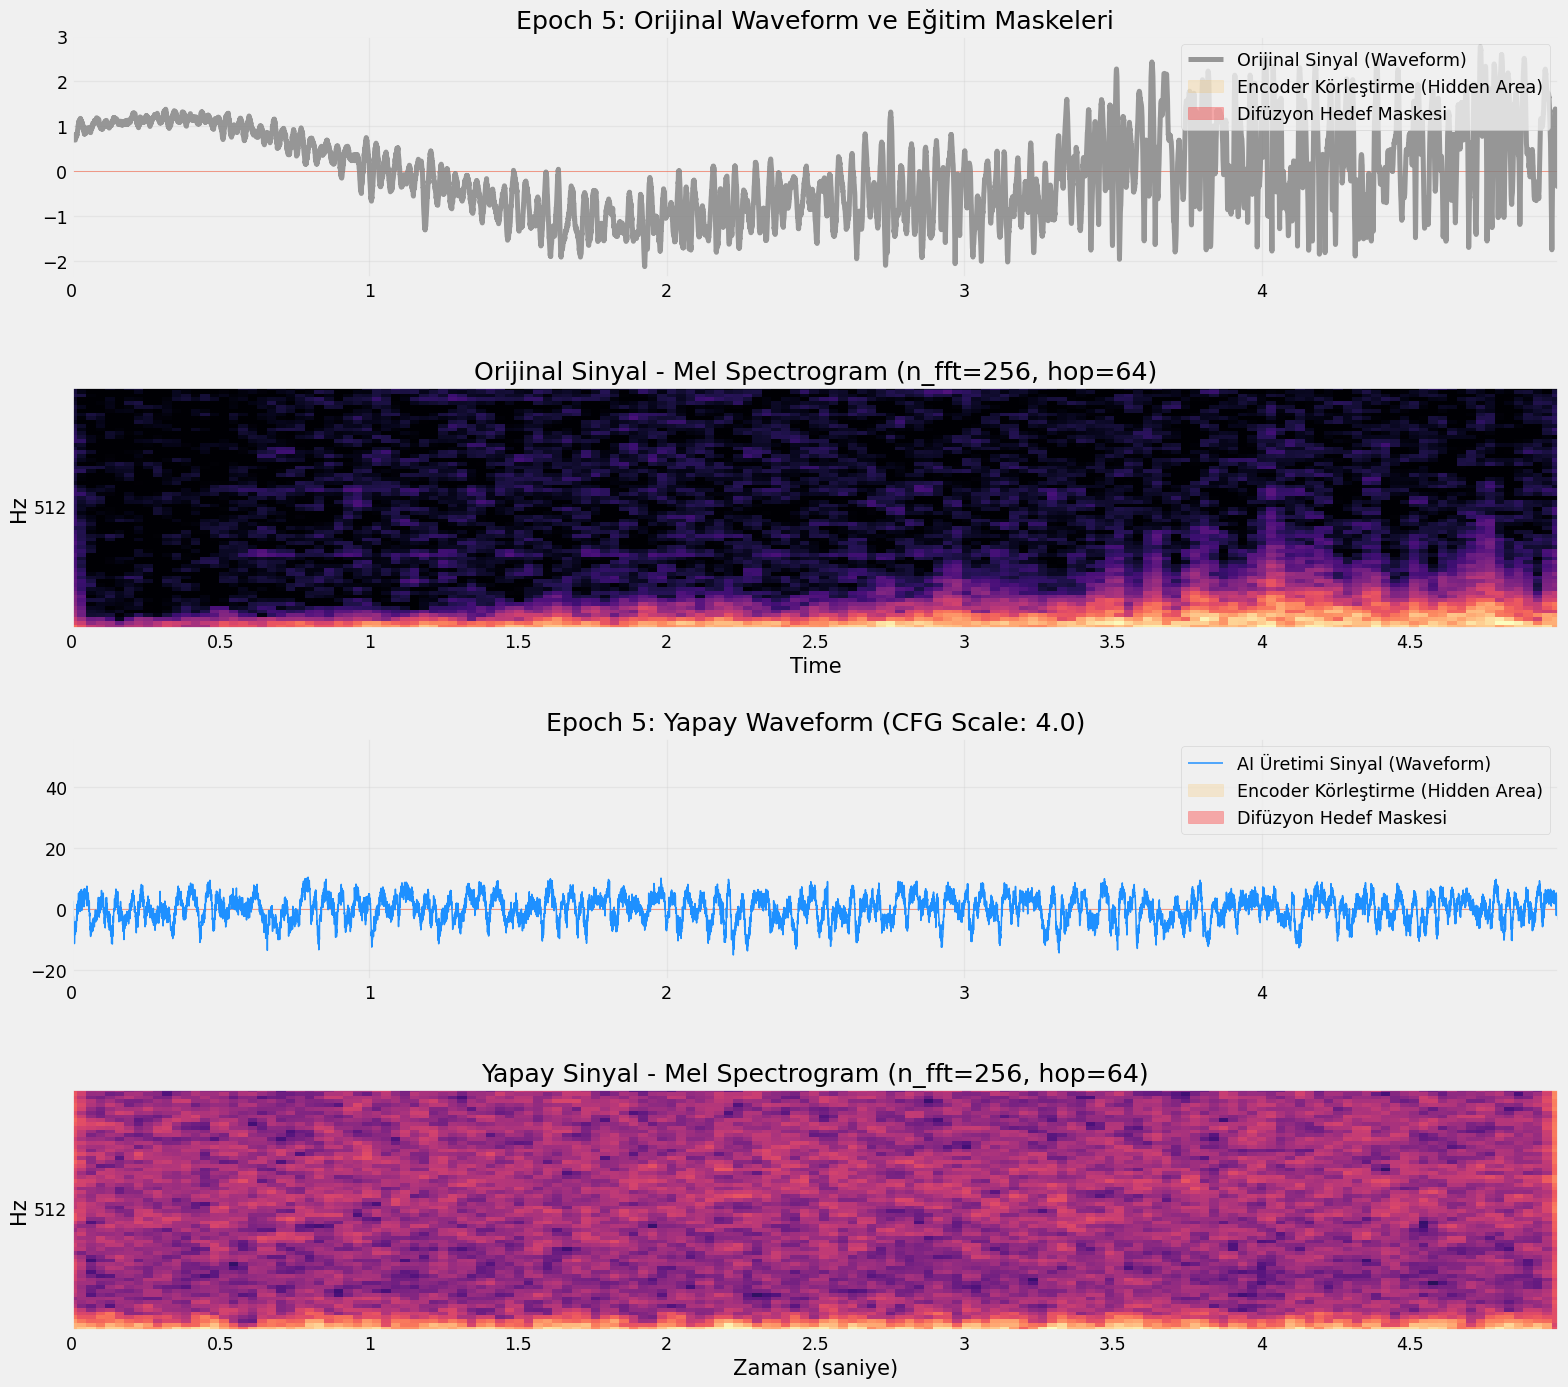

💾 Epoch 5 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 499/499 | Diffusion Loss (MSE): 0.0031
Epoch 6 Özet | Avg Diffusion Loss: 0.1221 | Süre: 117.8 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 6 - Loss: 0.1221)
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 499/499 | Diffusion Loss (MSE): 0.0196
Epoch 7 Özet | Avg Diffusion Loss: 0.1218 | Süre: 111.0 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 7 - Loss: 0.1218)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 499/499 | Diffusion Loss (MSE): 0.0816
Epoch 8 Özet | Avg Diffusion Loss: 0.1242 | Süre: 110.7 sn
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 499/499 | Diffusion Loss (MSE): 0.0281
Epoch 9 Özet | Avg Diffusion Loss: 0.1154 | Süre: 110.5 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 9 - Loss: 0.1154)
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 499/499 | Diffusion Loss (MSE): 0.0749
Epoch 10 Özet | Avg Diffusion Loss: 0.1109 | Süre: 110.5 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 10 - Loss: 0.1109)
Epoch 10 için sin

Ep 10 Denoising: 100%|██████████| 1000/1000 [07:48<00:00,  2.14it/s]


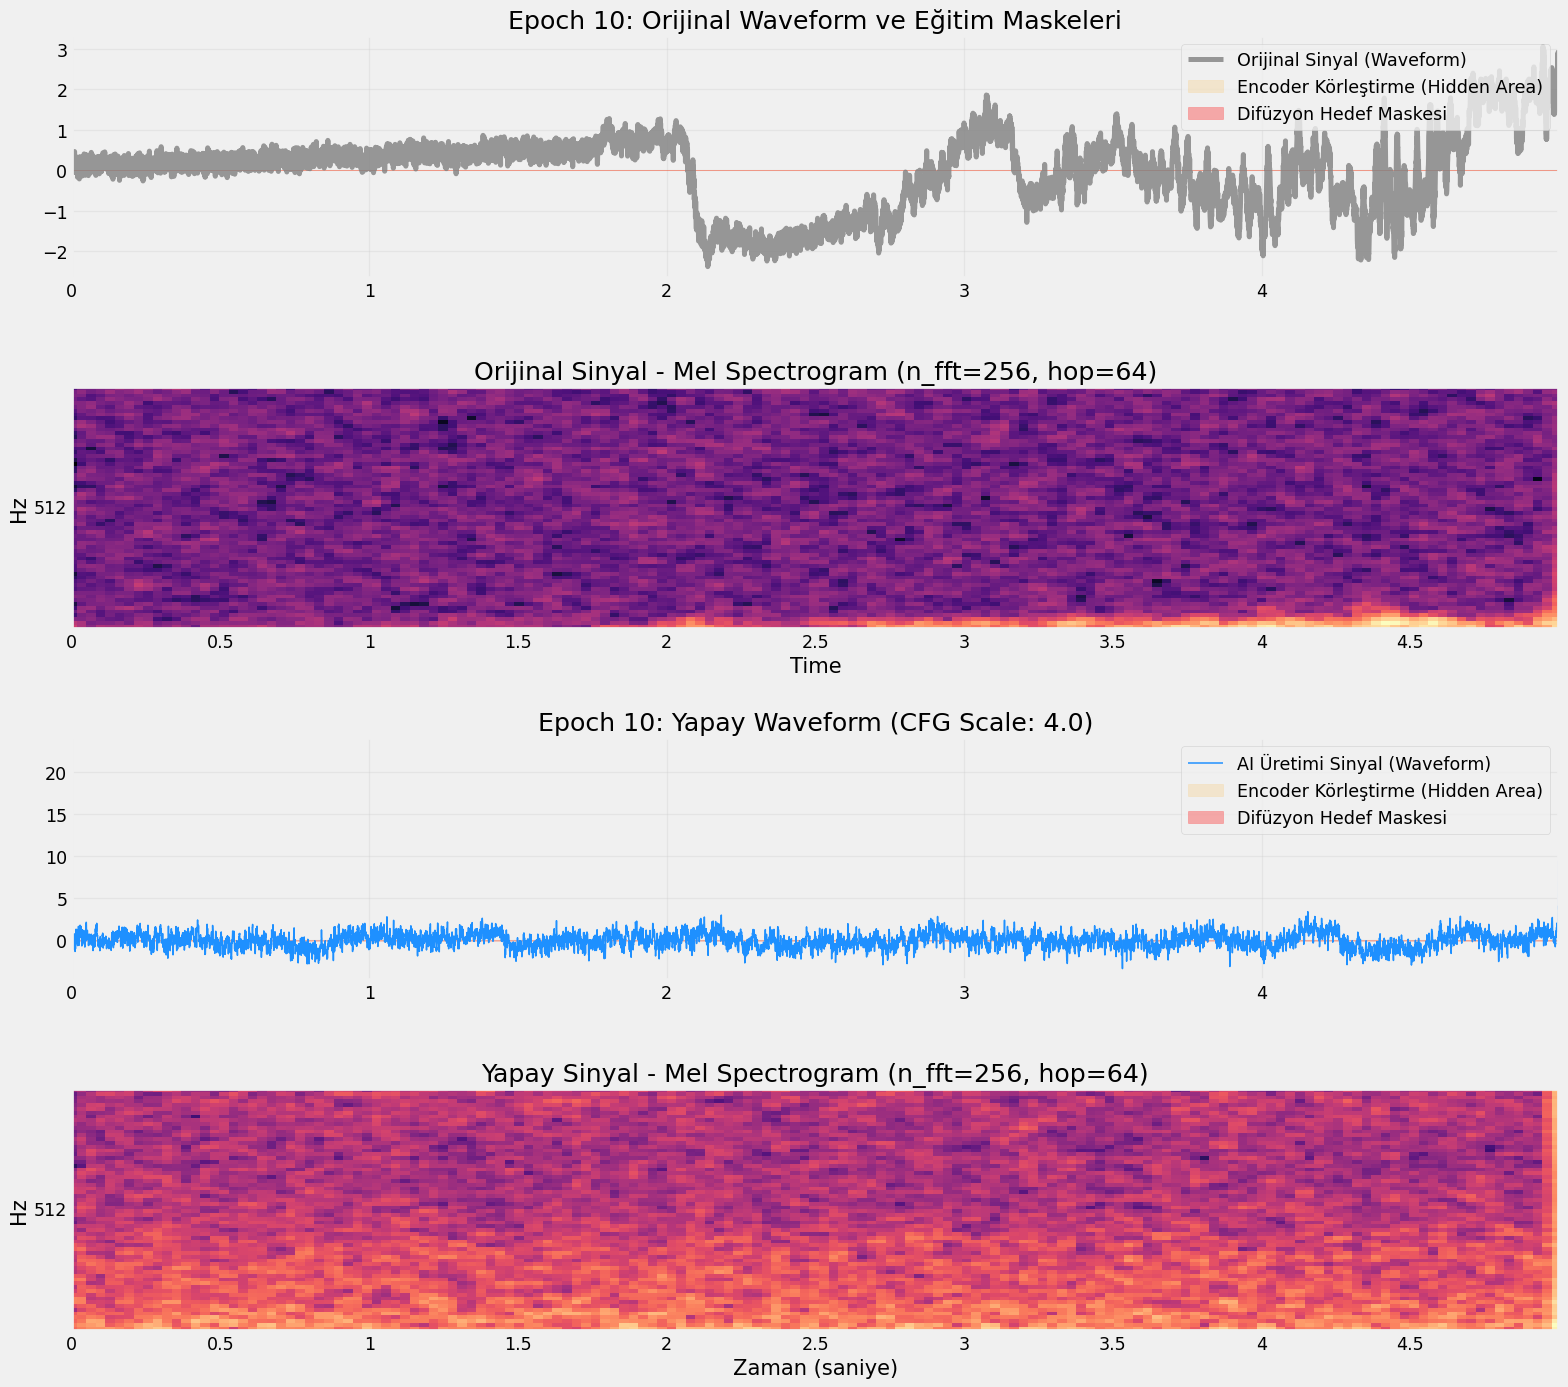

💾 Epoch 10 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 499/499 | Diffusion Loss (MSE): 0.4365
Epoch 11 Özet | Avg Diffusion Loss: 0.1166 | Süre: 117.3 sn
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 499/499 | Diffusion Loss (MSE): 0.0362
Epoch 12 Özet | Avg Diffusion Loss: 0.1196 | Süre: 110.6 sn
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 499/499 | Diffusion Loss (MSE): 0.3130
Epoch 13 Özet | Avg Diffusion Loss: 0.1173 | Süre: 110.7 sn
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 499/499 | Diffusion Loss (MSE): 0.0103
Epoch 14 Özet | Avg Diffusion Loss: 0.1111 | Süre: 110.6 sn
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 499/499 | Diffusion Loss (MSE): 0.2640
Epoch 15 Özet | Avg Diffusion Loss: 0.1133 | Süre: 110.6 sn
Epoch 15 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 15 Denoising: 100%|██████████| 1000/1000 [07:41<00:00,  2.17it/s]


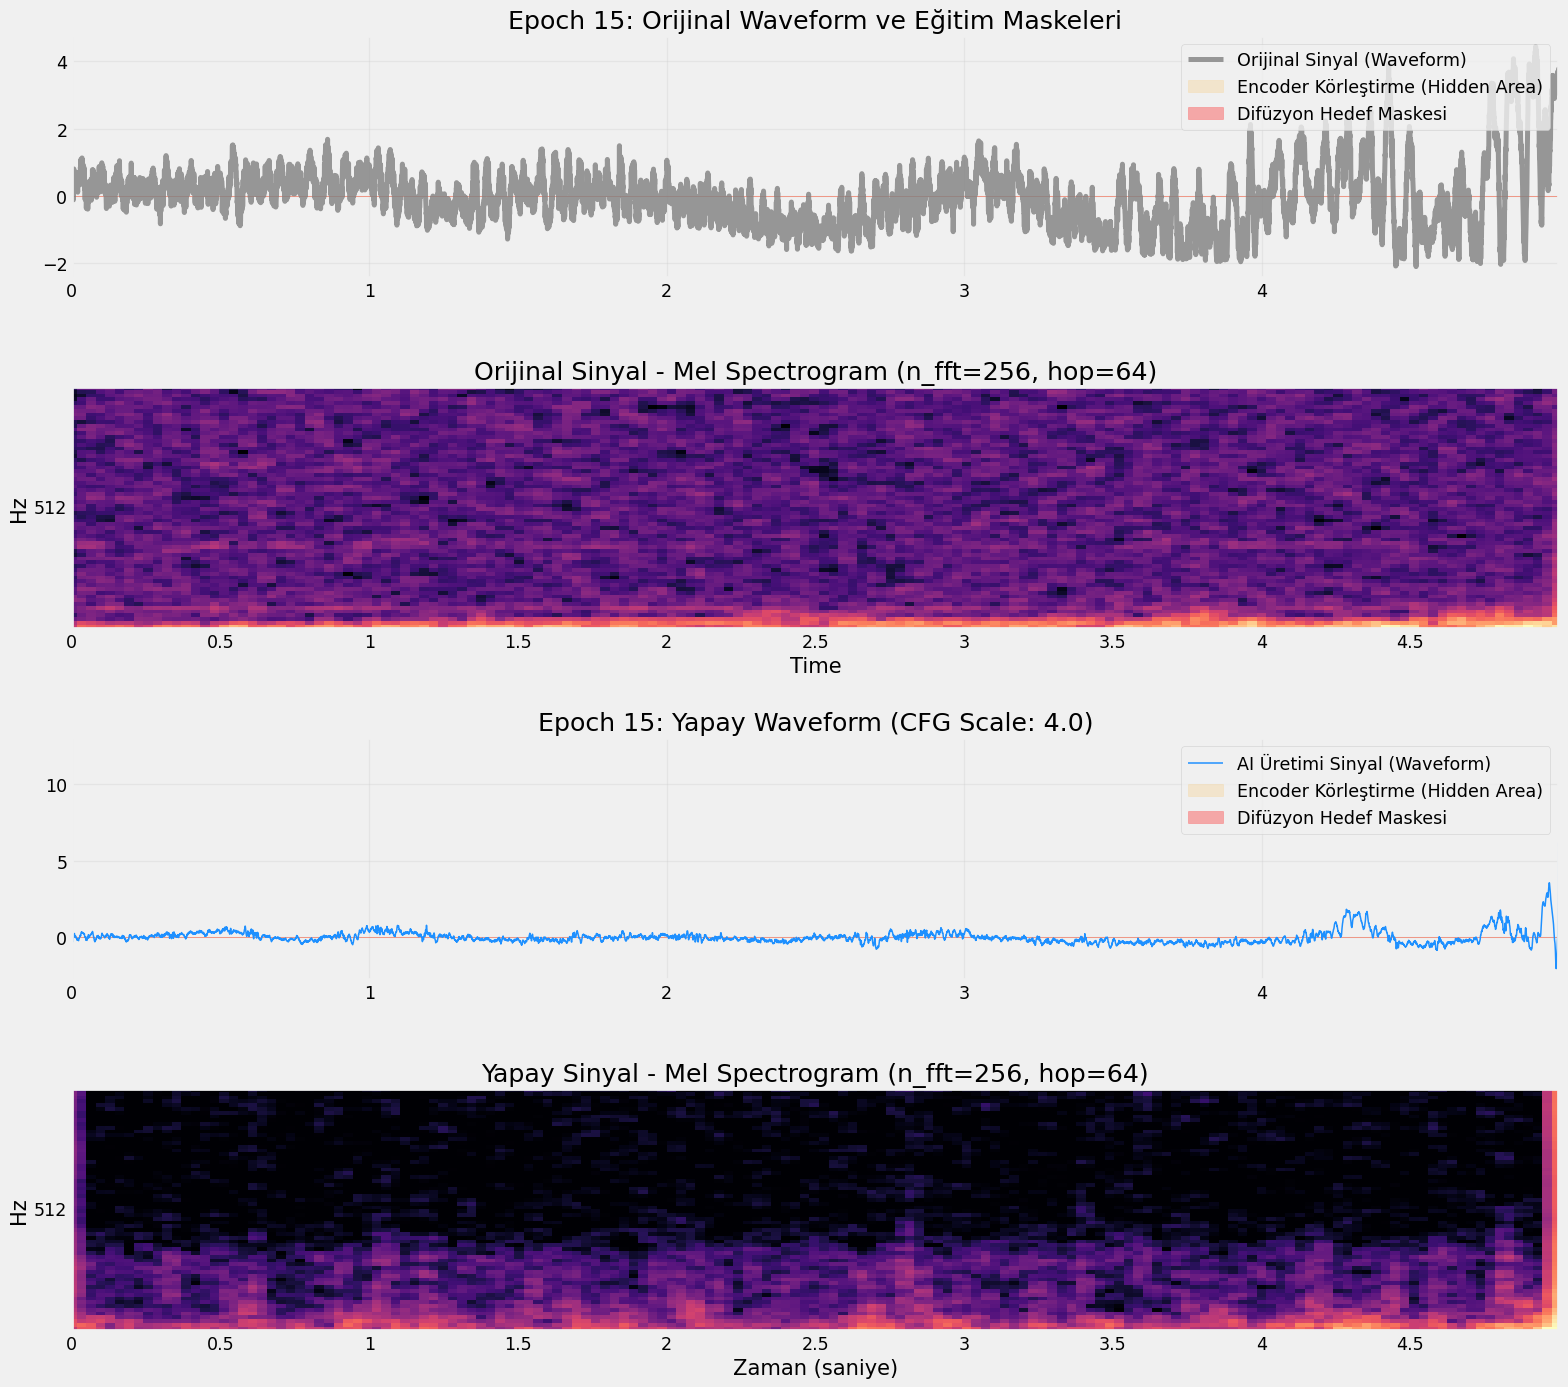

💾 Epoch 15 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 499/499 | Diffusion Loss (MSE): 0.0010
Epoch 16 Özet | Avg Diffusion Loss: 0.1151 | Süre: 117.8 sn
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 499/499 | Diffusion Loss (MSE): 0.0112
Epoch 17 Özet | Avg Diffusion Loss: 0.1157 | Süre: 110.6 sn
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 499/499 | Diffusion Loss (MSE): 0.2287
Epoch 18 Özet | Avg Diffusion Loss: 0.1085 | Süre: 110.6 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 18 - Loss: 0.1085)
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 499/499 | Diffusion Loss (MSE): 0.0791
Epoch 19 Özet | Avg Diffusion Loss: 0.1111 | Süre: 110.7 sn
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 499/499 | Diffusion Loss (MSE): 0.0008
Epoch 20 Özet | Avg Diffusion Loss: 0.1067 | Süre: 110.8 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 20 - Loss: 0.1067)
Epoch 20 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 20 Denoising: 100%|██████████| 1000/1000 [07:43<00:00,  2.16it/s]


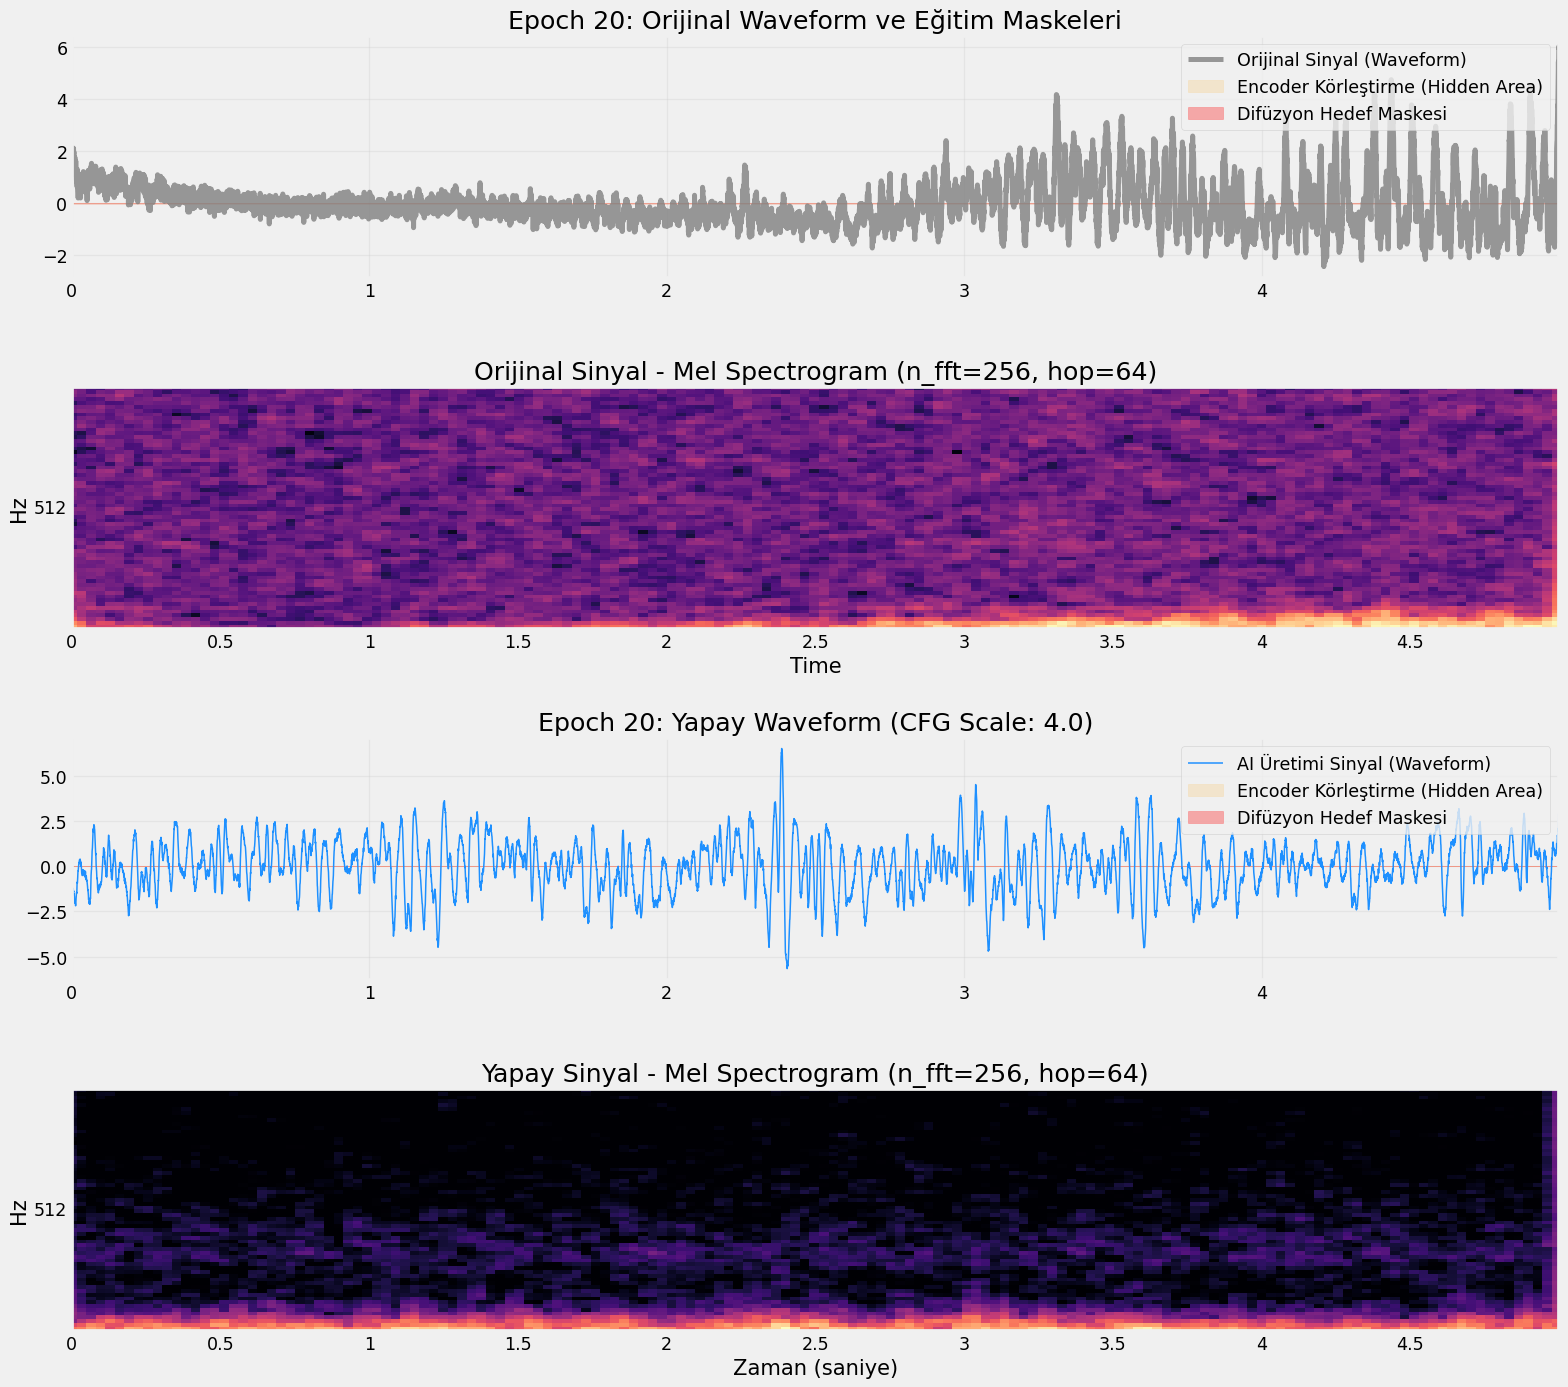

💾 Epoch 20 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 499/499 | Diffusion Loss (MSE): 0.0765
Epoch 21 Özet | Avg Diffusion Loss: 0.1145 | Süre: 117.1 sn
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 499/499 | Diffusion Loss (MSE): 0.0023
Epoch 22 Özet | Avg Diffusion Loss: 0.1037 | Süre: 111.2 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 22 - Loss: 0.1037)
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 499/499 | Diffusion Loss (MSE): 0.0180
Epoch 23 Özet | Avg Diffusion Loss: 0.1078 | Süre: 111.3 sn
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 499/499 | Diffusion Loss (MSE): 0.0952
Epoch 24 Özet | Avg Diffusion Loss: 0.1113 | Süre: 110.5 sn
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 499/499 | Diffusion Loss (MSE): 0.0554
Epoch 25 Özet | Avg Diffusion Loss: 0.1153 | Süre: 110.6 sn
Epoch 25 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 25 Denoising: 100%|██████████| 1000/1000 [07:34<00:00,  2.20it/s]


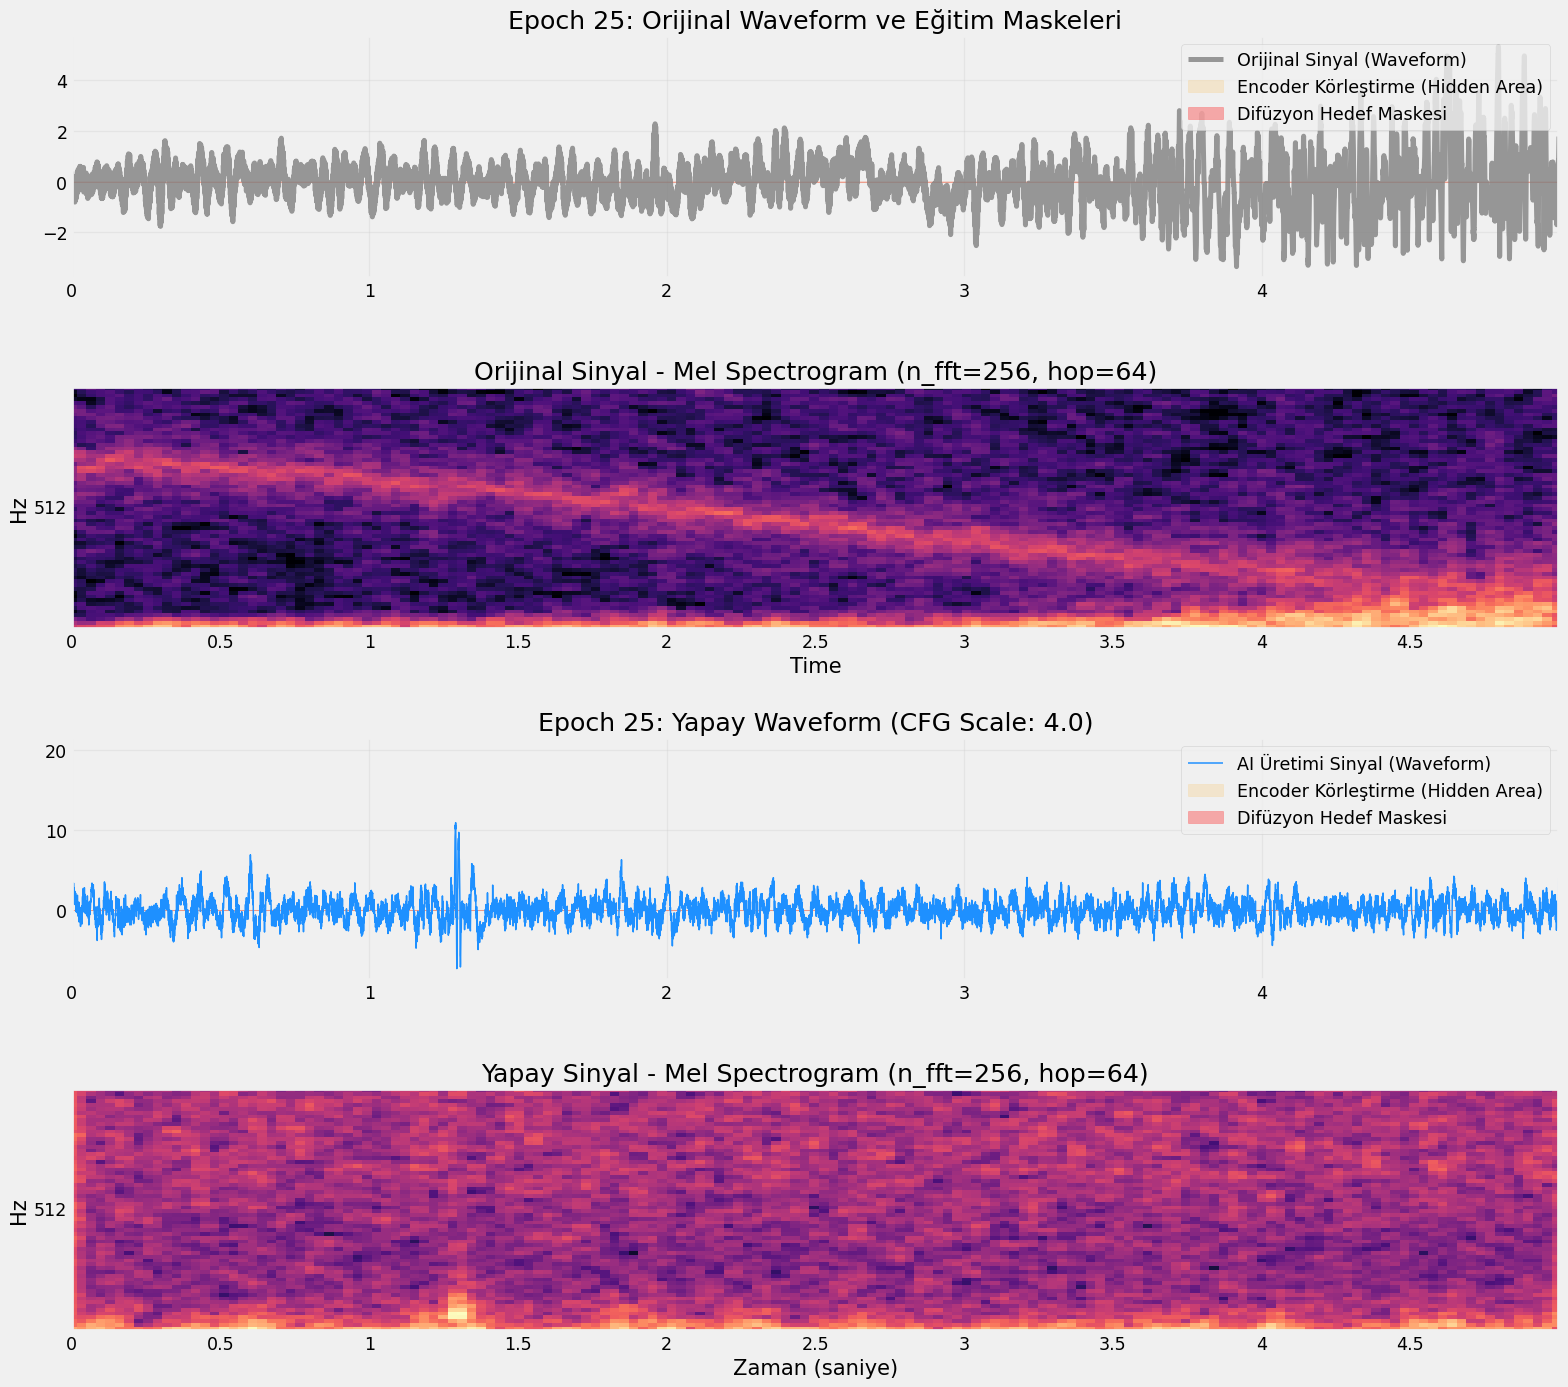

💾 Epoch 25 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 499/499 | Diffusion Loss (MSE): 0.0511
Epoch 26 Özet | Avg Diffusion Loss: 0.1039 | Süre: 117.1 sn
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 499/499 | Diffusion Loss (MSE): 0.0421
Epoch 27 Özet | Avg Diffusion Loss: 0.1164 | Süre: 110.5 sn
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 499/499 | Diffusion Loss (MSE): 0.0253
Epoch 28 Özet | Avg Diffusion Loss: 0.1130 | Süre: 110.6 sn
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 499/499 | Diffusion Loss (MSE): 0.0524
Epoch 29 Özet | Avg Diffusion Loss: 0.1081 | Süre: 111.2 sn
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 499/499 | Diffusion Loss (MSE): 0.1114
Epoch 30 Özet | Avg Diffusion Loss: 0.1134 | Süre: 110.9 sn
Epoch 30 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 30 Denoising: 100%|██████████| 1000/1000 [07:35<00:00,  2.19it/s]


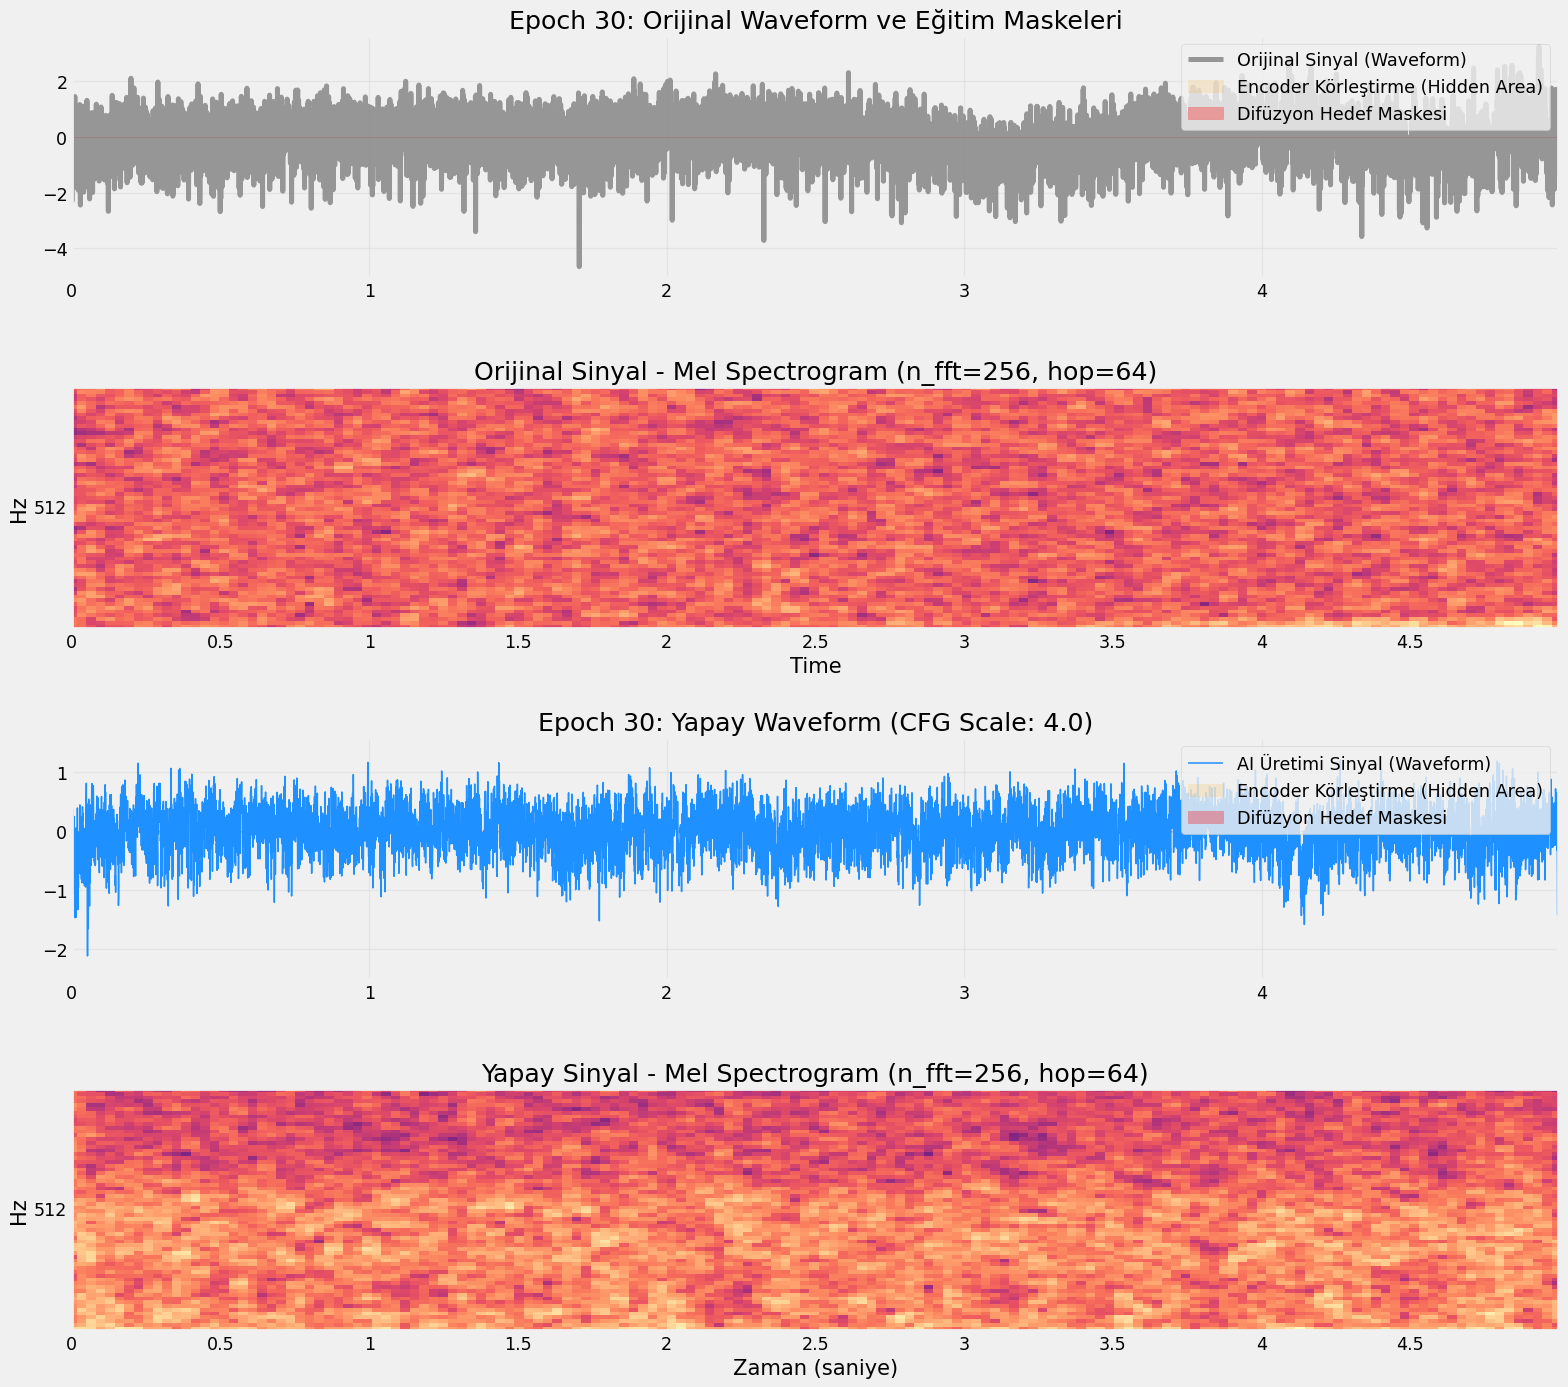

💾 Epoch 30 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 499/499 | Diffusion Loss (MSE): 0.0772
Epoch 31 Özet | Avg Diffusion Loss: 0.1049 | Süre: 117.1 sn
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 499/499 | Diffusion Loss (MSE): 0.0329
Epoch 32 Özet | Avg Diffusion Loss: 0.1111 | Süre: 110.5 sn
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 499/499 | Diffusion Loss (MSE): 0.0579
Epoch 33 Özet | Avg Diffusion Loss: 0.1100 | Süre: 110.5 sn
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 499/499 | Diffusion Loss (MSE): 0.0059
Epoch 34 Özet | Avg Diffusion Loss: 0.1082 | Süre: 110.6 sn
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 499/499 | Diffusion Loss (MSE): 0.0792
Epoch 35 Özet | Avg Diffusion Loss: 0.1145 | Süre: 110.6 sn
Epoch 35 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 35 Denoising:  16%|█▌        | 157/1000 [01:13<06:30,  2.16it/s]

In [11]:
import time
import tensorflow as tf
import os

EPOCHS = 500
best_diff_loss = float('inf') 
best_epoch_num = 0

# CFG Gücünü buradan yönetebilirsin (Vitrin çizimleri için)
CFG_SCALE = 4.0 

weights_dir = os.path.join(MODEL_FOLDER, "weights")
os.makedirs(weights_dir, exist_ok=True)

for epoch in range(EPOCHS):
    start = time.time()
    
    epoch_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        enc_masks = tf.convert_to_tensor(batch_data[:, :, 2:3], dtype=tf.float32)
        
        loss = train_step(real_sigs, peaks, enc_masks)
        
        epoch_loss.append(loss)
        
        print(f"Epoch {epoch+1} | Step {step+1}/{total_steps} | Diffusion Loss (MSE): {loss:.4f}", end='\r', flush=True)

    avg_loss = tf.reduce_mean(epoch_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | Avg Diffusion Loss: {avg_loss:.4f} | Süre: {time.time() - start:.1f} sn")
    
    # BEST EPOCH TAKİBİ
    if avg_loss < best_diff_loss:
        best_diff_loss = avg_loss
        best_epoch_num = epoch + 1
        print(f"🌟 Yeni En İyi Başarı! (Best Epoch şu an: {best_epoch_num} - Loss: {best_diff_loss:.4f})")

    if (epoch + 1) % 5 == 0:
        # +++ GÜNCELLEME: guidance_scale parametresi eklendi +++
        visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, MODEL_FOLDER, guidance_scale=CFG_SCALE)
        
        enc_weight_path = os.path.join(weights_dir, f"encoder_epoch_{epoch+1}.weights.h5")
        unet_weight_path = os.path.join(weights_dir, f"diffusion_unet_epoch_{epoch+1}.weights.h5")
        
        encoder.save_weights(enc_weight_path)
        diffusion_unet.save_weights(unet_weight_path) 
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları başarıyla kaydedildi.")

print(f"\n✅ EĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")